# Tax Fraud Dataset — Exploratory Data Analysis (EDA)

**Goal:** explore the *cleaned* dataset visually and statistically to
understand what separates fraud from non-fraud cases, spot redundant /
multicollinear features, and decide what preprocessing & feature
engineering the modeling stage will need.

Input: `tax_fraud_dataset_cleaned.csv` (output of `Cleaning.ipynb`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

# Project structure: this notebook lives in notebooks/, data lives in data/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
PALETTE = {0: 'steelblue', 1: 'indianred'}

## 1. Load Cleaned Data

In [2]:
df = pd.read_csv(DATA_DIR / 'tax_fraud_dataset_cleaned.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()


Shape: 50000 rows, 25 columns
Missing values: 0


,Taxpayer_ID,Business_Type,Region,Years_in_Business,Employee_Count,Annual_Revenue,Annual_Expenses,Net_Profit,Taxable_Income,Expected_Tax,Declared_Tax,VAT_Collected,VAT_Paid,Previous_Audits,Previous_Violations,Late_Payments,Industry_Risk,Cash_Transactions_Percentage,Missing_Documents,Invoice_Mismatch,Expense_Ratio,Profit_Margin,Revenue_per_Employee,Tax_Gap,Fraud
0,100000,Restaurant,Cairo,10,9,1892448.36,839511.26,1052937.10,919634.40,206917.74,200930.13,264942.77,117531.58,2,0,0,Medium,58.87,0,0,0.444,0.556,210272.04,5987.61,0
1,100001,Pharmacy,Giza,0,17,2129742.33,923661.40,1206080.92,1078021.30,242554.79,234562.43,298163.93,129312.60,1,0,1,Low,5.98,0,0,0.434,0.566,125278.96,7992.36,0
2,100002,Restaurant,Sharqia,4,8,789223.93,334017.67,455206.26,420736.46,94665.70,81056.42,110491.35,46762.47,1,0,0,Medium,69.98,4,1,0.423,0.577,98652.99,13609.28,1
3,100003,Manufacturing,Cairo,7,8,427211.55,361951.79,65259.77,58963.05,13266.69,12816.14,59809.62,50673.25,2,0,0,Medium,42.56,1,0,0.847,0.153,53401.44,450.54,0
4,100004,Import/Export,Sharqia,3,8,1516452.68,831833.16,684619.52,588453.59,132402.06,130966.03,212303.38,116456.64,0,1,2,High,39.09,1,0,0.549,0.451,189556.58,1436.03,0


In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ('Taxpayer_ID', 'Fraud')]
cat_cols = ['Business_Type', 'Region', 'Industry_Risk']
print("Numeric feature columns:", num_cols)
print("Categorical feature columns:", cat_cols)


Numeric feature columns: ['Years_in_Business', 'Employee_Count', 'Annual_Revenue', 'Annual_Expenses', 'Net_Profit', 'Taxable_Income', 'Expected_Tax', 'Declared_Tax', 'VAT_Collected', 'VAT_Paid', 'Previous_Audits', 'Previous_Violations', 'Late_Payments', 'Cash_Transactions_Percentage', 'Missing_Documents', 'Invoice_Mismatch', 'Expense_Ratio', 'Profit_Margin', 'Revenue_per_Employee', 'Tax_Gap']
Categorical feature columns: ['Business_Type', 'Region', 'Industry_Risk']


## 2. Target Variable — `Fraud`

How imbalanced is the classification problem?


Fraud
0    44639
1     5361
Name: count, dtype: int64
Fraud
0    89.28
1    10.72
Name: proportion, dtype: float64


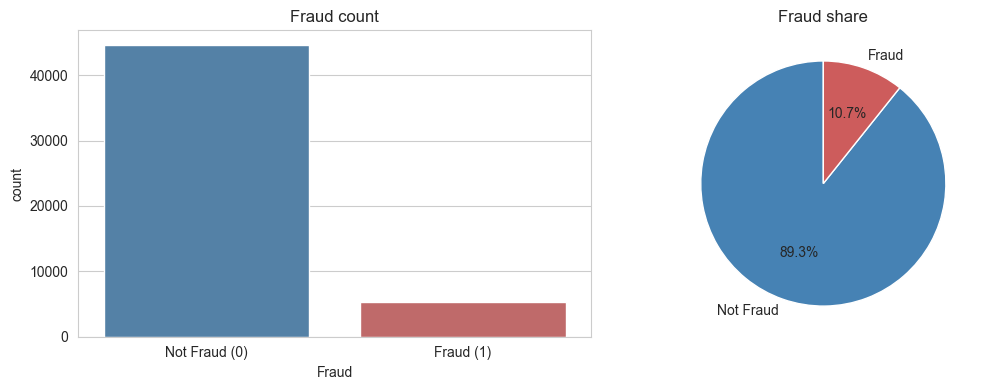

In [4]:
fraud_counts = df['Fraud'].value_counts()
fraud_pct = df['Fraud'].value_counts(normalize=True) * 100

print(fraud_counts)
print(fraud_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='Fraud', data=df, hue='Fraud', palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title('Fraud count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Fraud (0)', 'Fraud (1)'])

axes[1].pie(fraud_counts, labels=['Not Fraud', 'Fraud'], autopct='%1.1f%%',
            colors=[PALETTE[0], PALETTE[1]], startangle=90)
axes[1].set_title('Fraud share')
plt.tight_layout()
plt.show()


**Note:** the ~89% / 11% split is a significant class imbalance. Plain
accuracy will be misleading later (a model predicting "not fraud" every
time would already score ~89%) — this is something to account for during
modeling with class weights, resampling (e.g. SMOTE), or by evaluating with
precision/recall/F1/ROC-AUC instead of accuracy.


## 3. Numeric Feature Distributions

Histograms for every numeric feature, to see scale, skew, and general shape
before deciding on scaling/transformations.


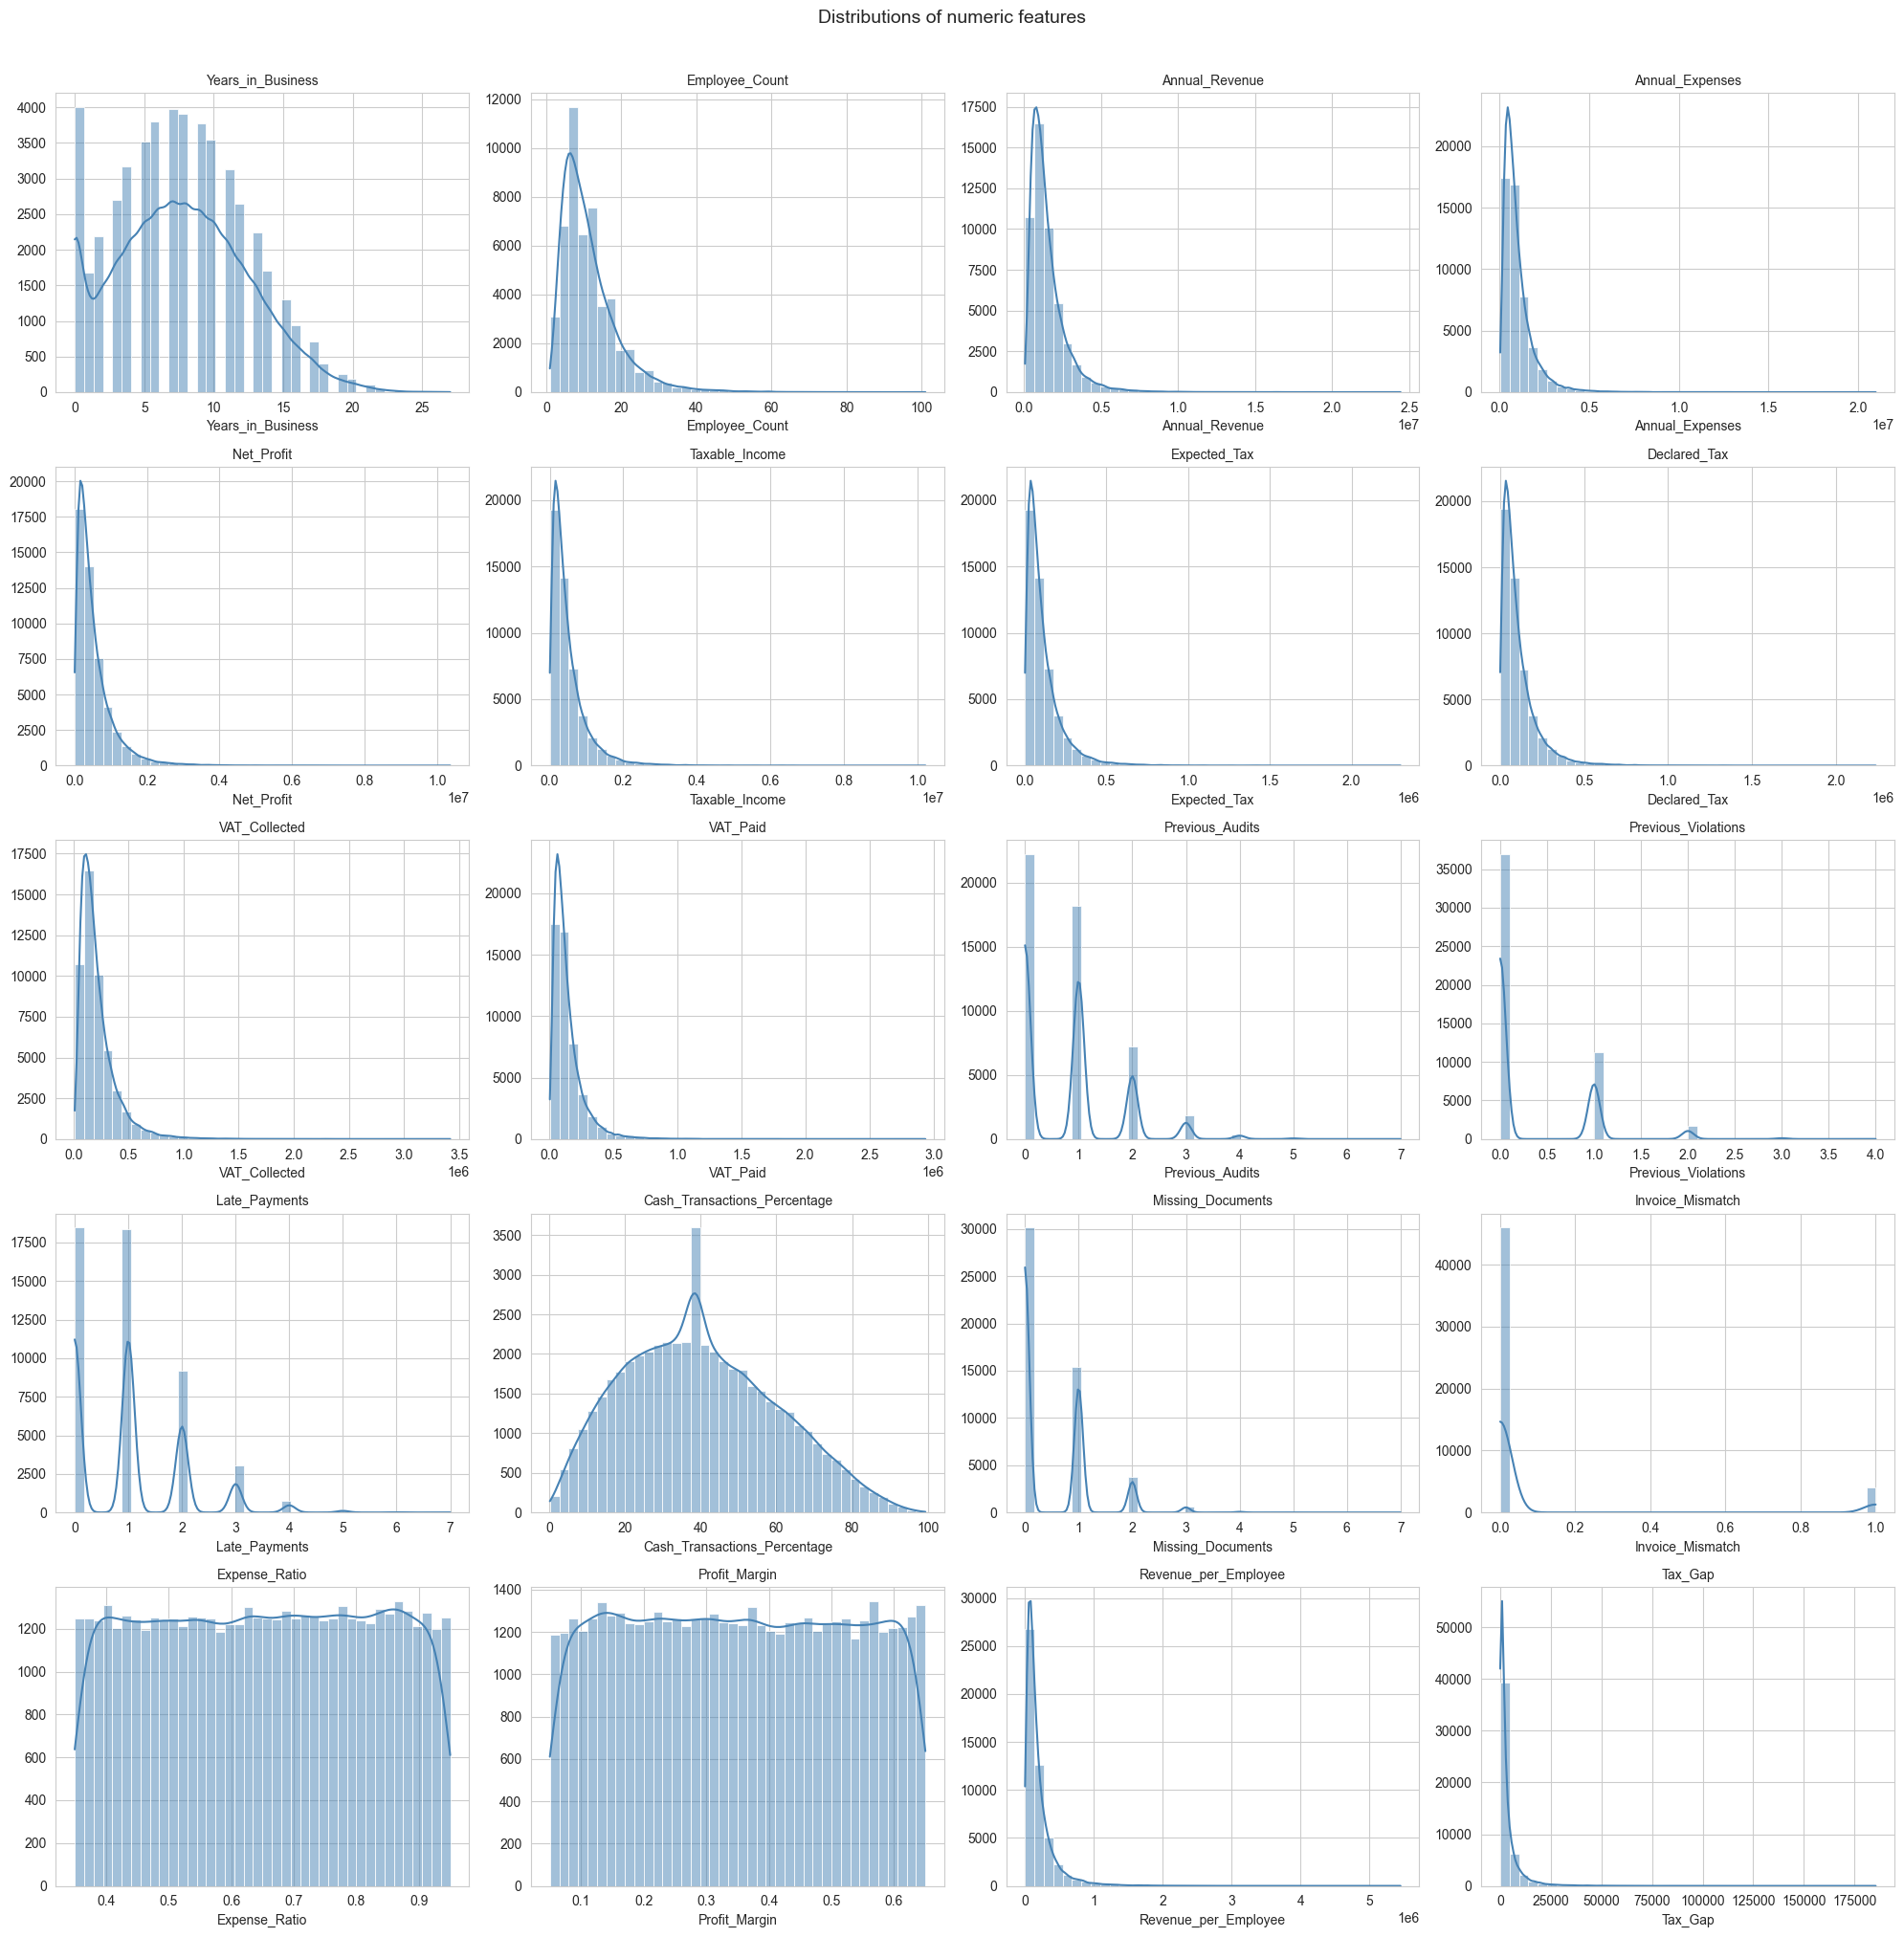

In [5]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], bins=40, color='steelblue', ax=ax, kde=True)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.suptitle('Distributions of numeric features', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


Financial columns (`Annual_Revenue`, `Net_Profit`, `Tax_Gap`, etc.) are
right-skewed, as expected for money data — most businesses cluster at lower
values with a long tail of larger ones. This is normal, not an error (we
already validated that in `Cleaning.ipynb`), but it's worth remembering for
modeling: tree-based models handle skew natively, while linear models or
KNN would benefit from a log-transform or robust scaling.


## 4. Categorical Feature Distributions

How many businesses fall into each category?


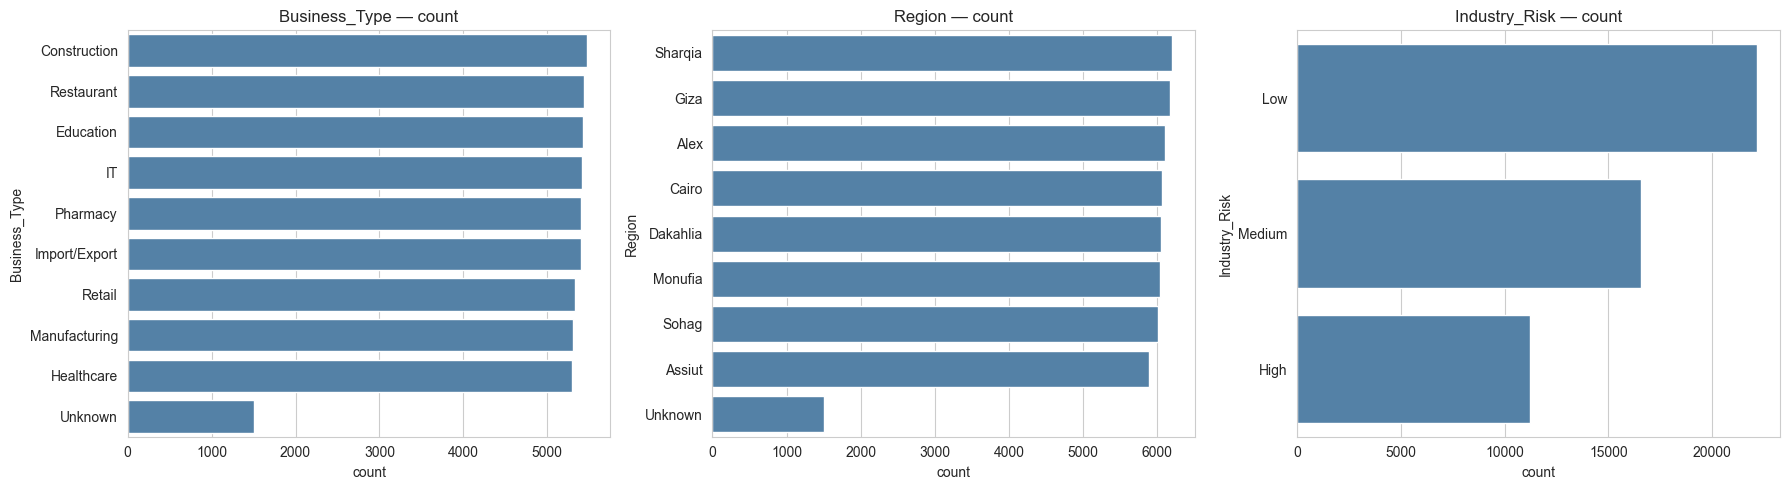

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, color='steelblue', ax=ax)
    ax.set_title(f'{col} — count')
plt.tight_layout()
plt.show()


## 5. Numeric Features vs Fraud

Box plots comparing each numeric feature's distribution between fraud and
non-fraud rows — this is where we look for actual separation, not just
raw distribution shape.


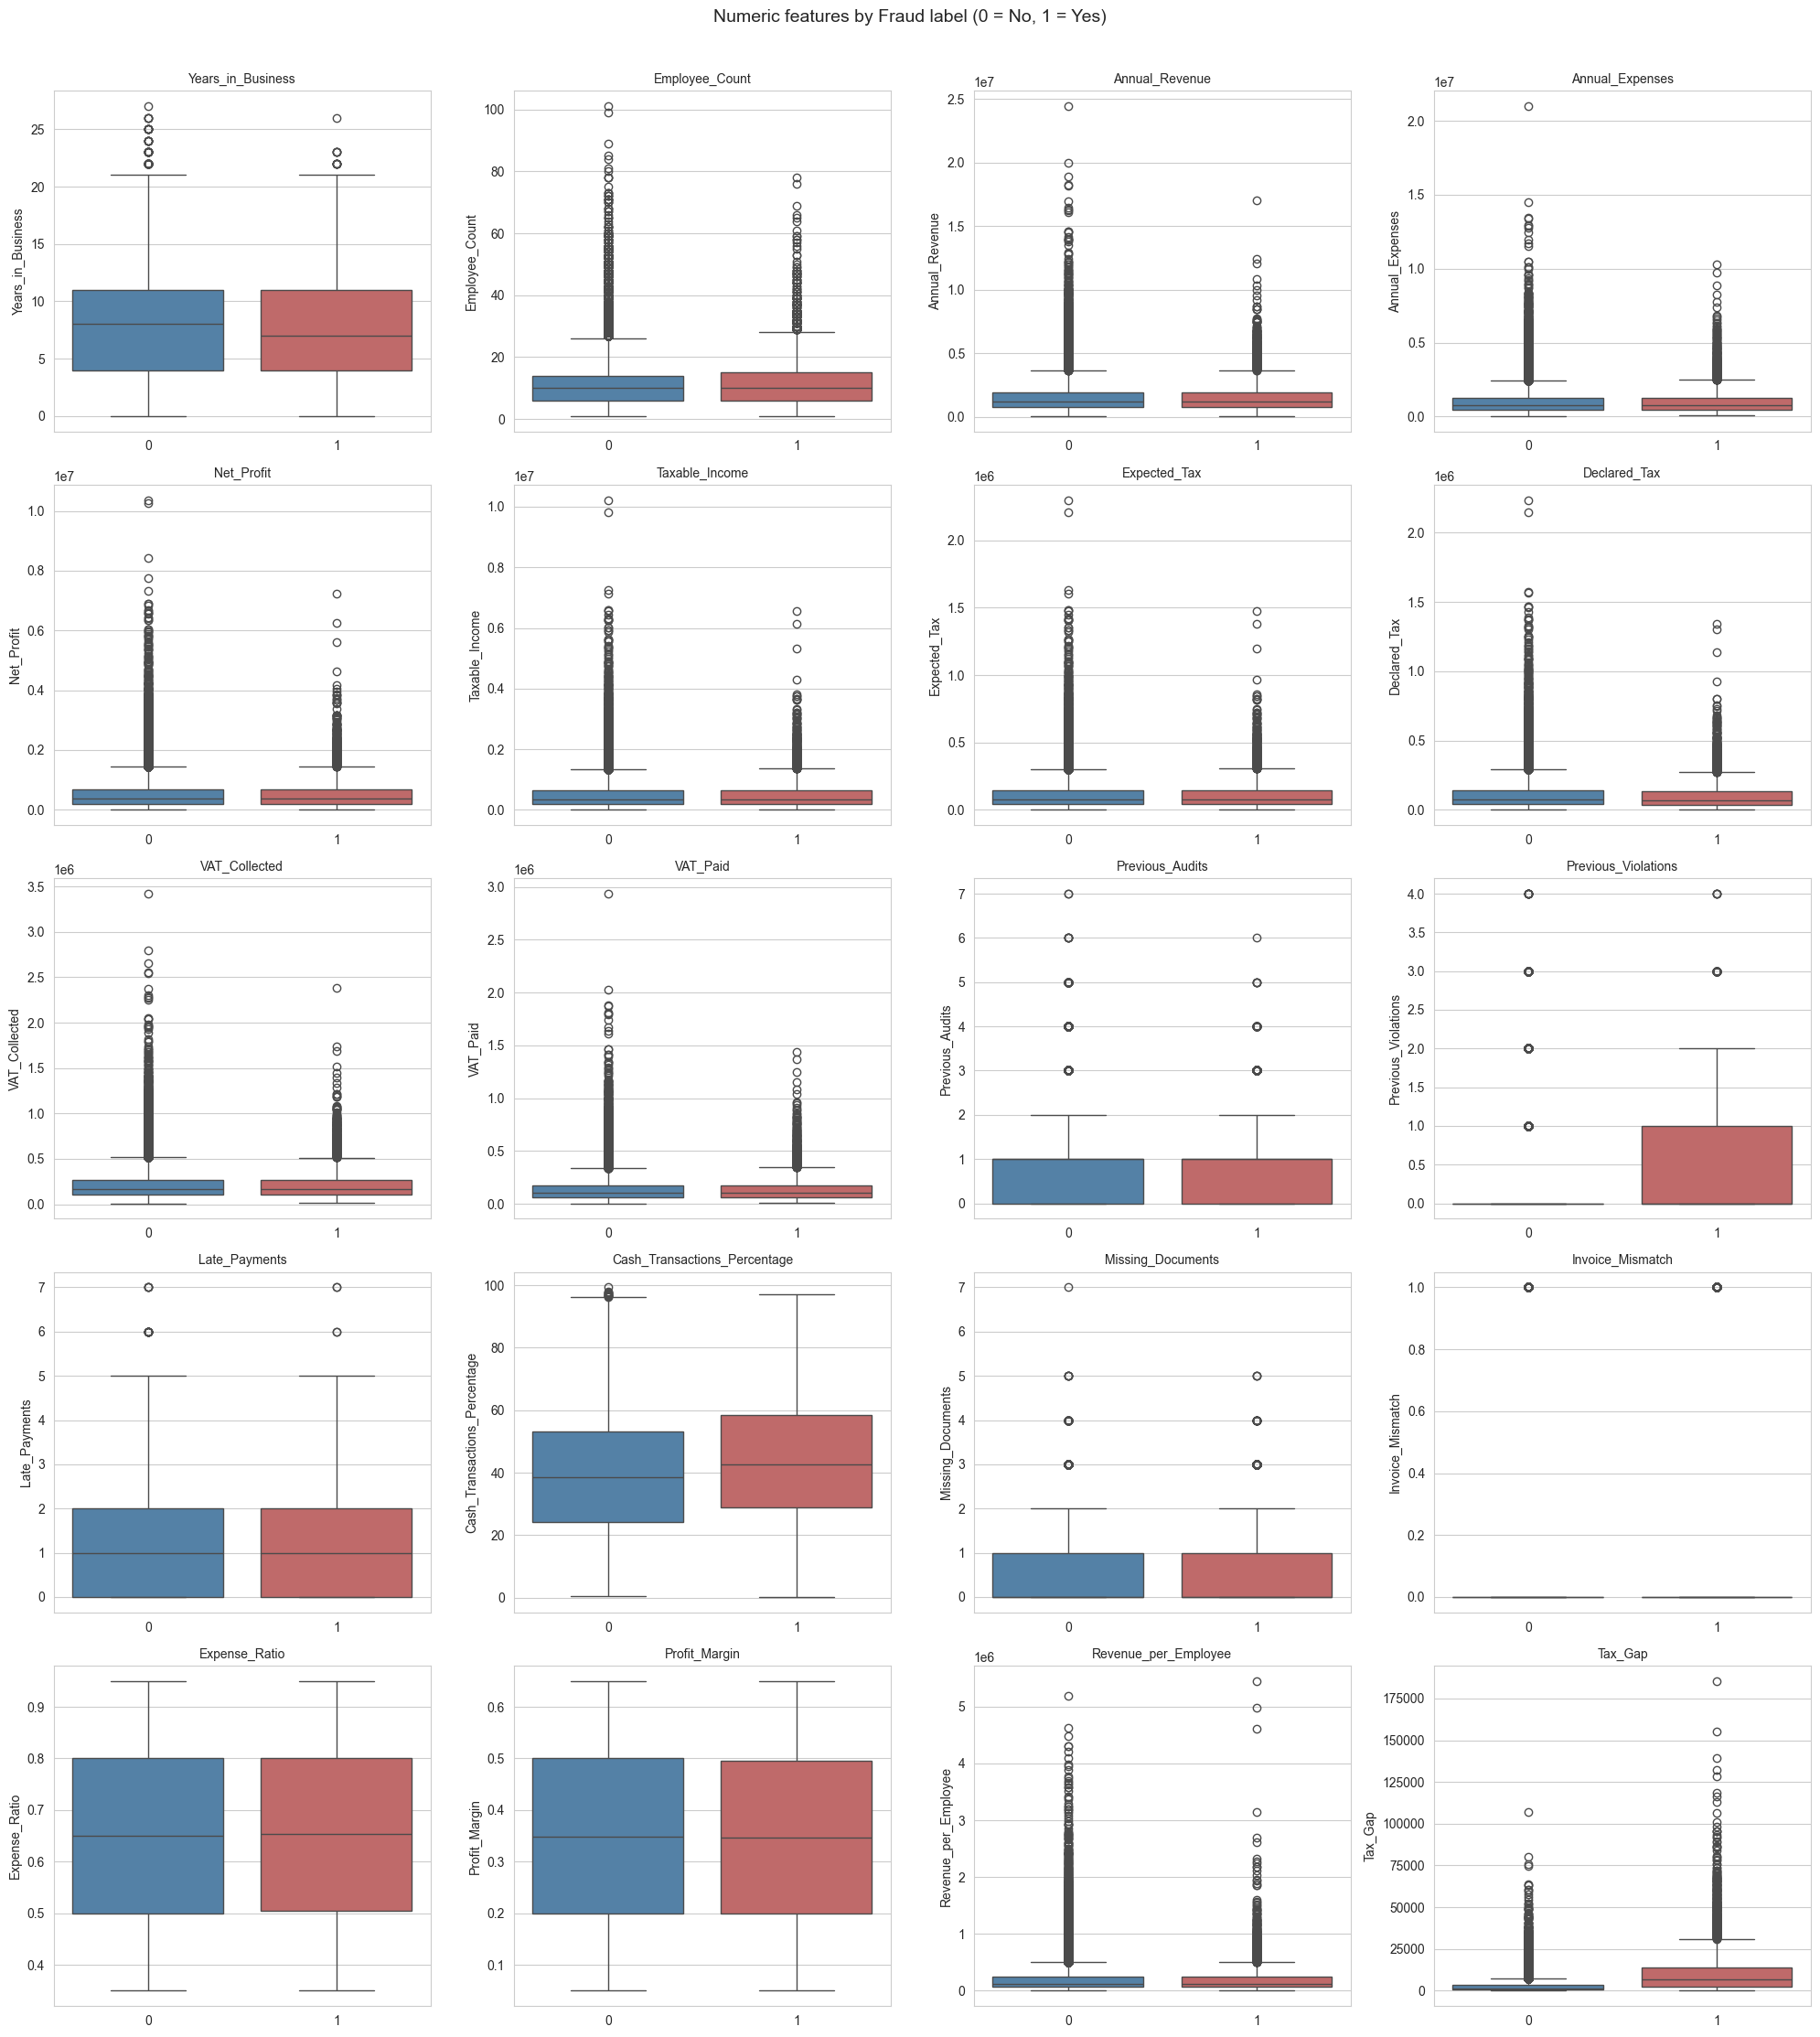

In [7]:
fig, axes = plt.subplots(5, 4, figsize=(20, 22))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x='Fraud', y=col, data=df, hue='Fraud', palette=PALETTE, legend=False, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.suptitle('Numeric features by Fraud label (0 = No, 1 = Yes)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


In [8]:
# Rank features by how much their mean differs between fraud and non-fraud
means = df.groupby('Fraud')[num_cols].mean().T
means.columns = ['Not_Fraud_mean', 'Fraud_mean']
means['pct_diff'] = ((means['Fraud_mean'] - means['Not_Fraud_mean']) / means['Not_Fraud_mean'].abs() * 100)
means.sort_values('pct_diff', key=abs, ascending=False).round(2)


,Not_Fraud_mean,Fraud_mean,pct_diff
Tax_Gap,2694.07,11028.57,309.36
Invoice_Mismatch,0.07,0.14,95.10
Previous_Violations,0.28,0.49,73.79
Missing_Documents,0.48,0.66,36.32
Cash_Transactions_Percentage,39.50,43.84,11.01
Declared_Tax,109234.08,101039.01,-7.50
Years_in_Business,7.68,7.33,-4.47
Late_Payments,1.00,1.01,1.52
Employee_Count,11.43,11.55,1.08
Annual_Expenses,998672.82,1006105.98,0.74


## 6. Categorical Features vs Fraud

Does fraud rate differ meaningfully across business type, region, or
industry risk level?


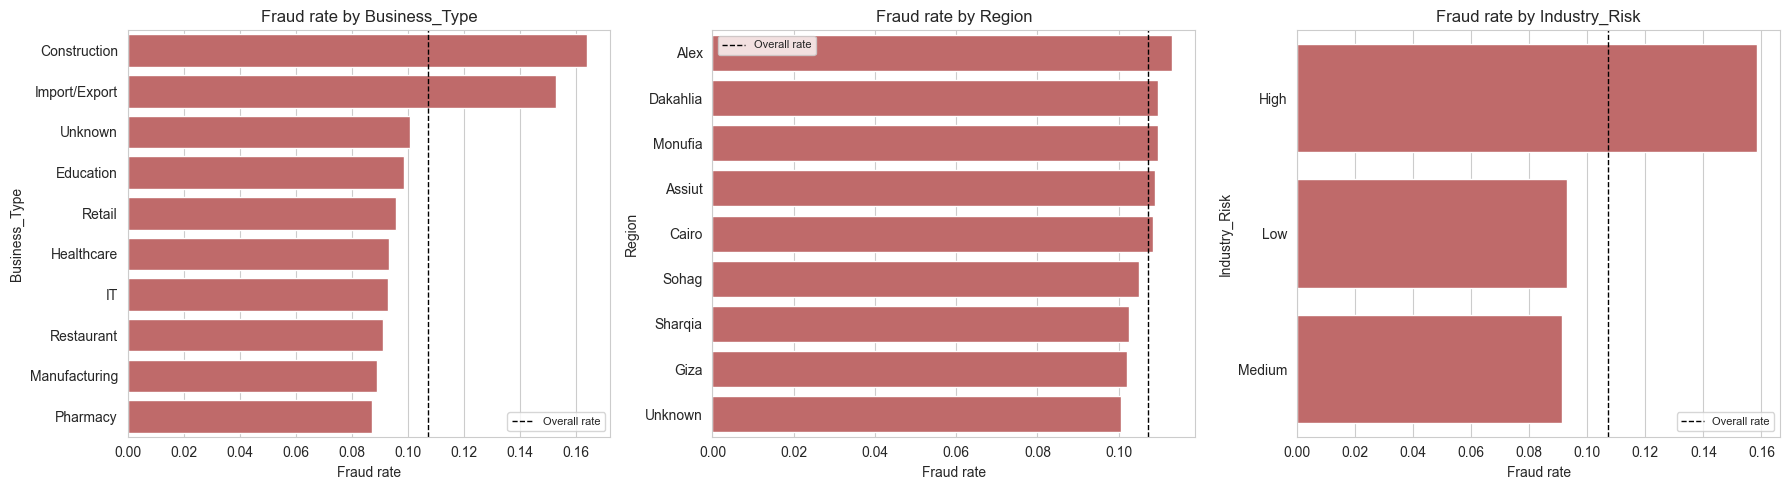

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    rate = df.groupby(col)['Fraud'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, color='indianred', ax=ax)
    ax.axvline(df['Fraud'].mean(), color='black', linestyle='--', linewidth=1, label='Overall rate')
    ax.set_title(f'Fraud rate by {col}')
    ax.set_xlabel('Fraud rate')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [10]:
for col in cat_cols:
    print(f"\n--- Fraud rate by {col} ---")
    print(df.groupby(col)['Fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False).round(3))



--- Fraud rate by Business_Type ---
                mean  count
Business_Type              
Construction   0.164   5478
Import/Export  0.153   5399
Unknown        0.101   1500
Education      0.099   5430
Retail         0.096   5328
Healthcare     0.093   5299
IT             0.093   5413
Restaurant     0.091   5442
Manufacturing  0.089   5308
Pharmacy       0.087   5403

--- Fraud rate by Region ---
           mean  count
Region                
Alex      0.113   6097
Dakahlia  0.110   6049
Monufia   0.110   6031
Assiut    0.109   5881
Cairo     0.108   6065
Sohag     0.105   6012
Sharqia   0.103   6199
Giza      0.102   6166
Unknown   0.101   1500

--- Fraud rate by Industry_Risk ---
                mean  count
Industry_Risk              
High           0.158  11244
Low            0.093  22170
Medium         0.091  16586


## 7. Correlation with Fraud

Ranking every numeric feature by its (point-biserial) correlation with the
`Fraud` target.


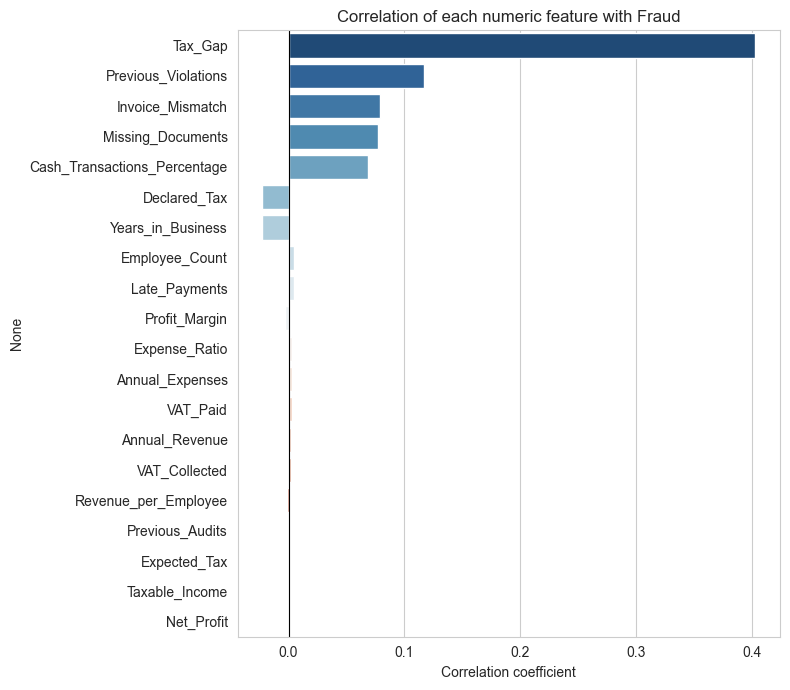

Tax_Gap                         0.403
Previous_Violations             0.117
Invoice_Mismatch                0.079
Missing_Documents               0.077
Cash_Transactions_Percentage    0.068
Declared_Tax                   -0.023
Years_in_Business              -0.023
Employee_Count                  0.005
Late_Payments                   0.005
Profit_Margin                  -0.003
Expense_Ratio                   0.003
Annual_Expenses                 0.003
VAT_Paid                        0.003
Annual_Revenue                  0.002
VAT_Collected                   0.002
Revenue_per_Employee           -0.001
Previous_Audits                 0.000
Expected_Tax                    0.000
Taxable_Income                  0.000
Net_Profit                      0.000
Name: Fraud, dtype: float64

In [11]:
corr_with_fraud = df[num_cols + ['Fraud']].corr()['Fraud'].drop('Fraud').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 7))
sns.barplot(x=corr_with_fraud.values, y=corr_with_fraud.index,
            hue=corr_with_fraud.index, palette='RdBu_r', legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of each numeric feature with Fraud')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

corr_with_fraud.round(3)


`Tax_Gap` stands out as by far the strongest single predictor, followed by
`Previous_Violations`, `Invoice_Mismatch`, `Missing_Documents`, and
`Cash_Transactions_Percentage`. Most raw financial-size columns (revenue,
profit, VAT, etc.) show almost no linear relationship with fraud on their
own — fraud in this data is about specific *behavioral red flags*, not
business size.


## 8. Full Correlation Heatmap & Multicollinearity Check

Two different features can each correlate with fraud, but if they're also
almost perfectly correlated *with each other*, keeping both adds
redundancy (and can hurt some models) without adding information. Let's
check the full numeric feature correlation matrix.


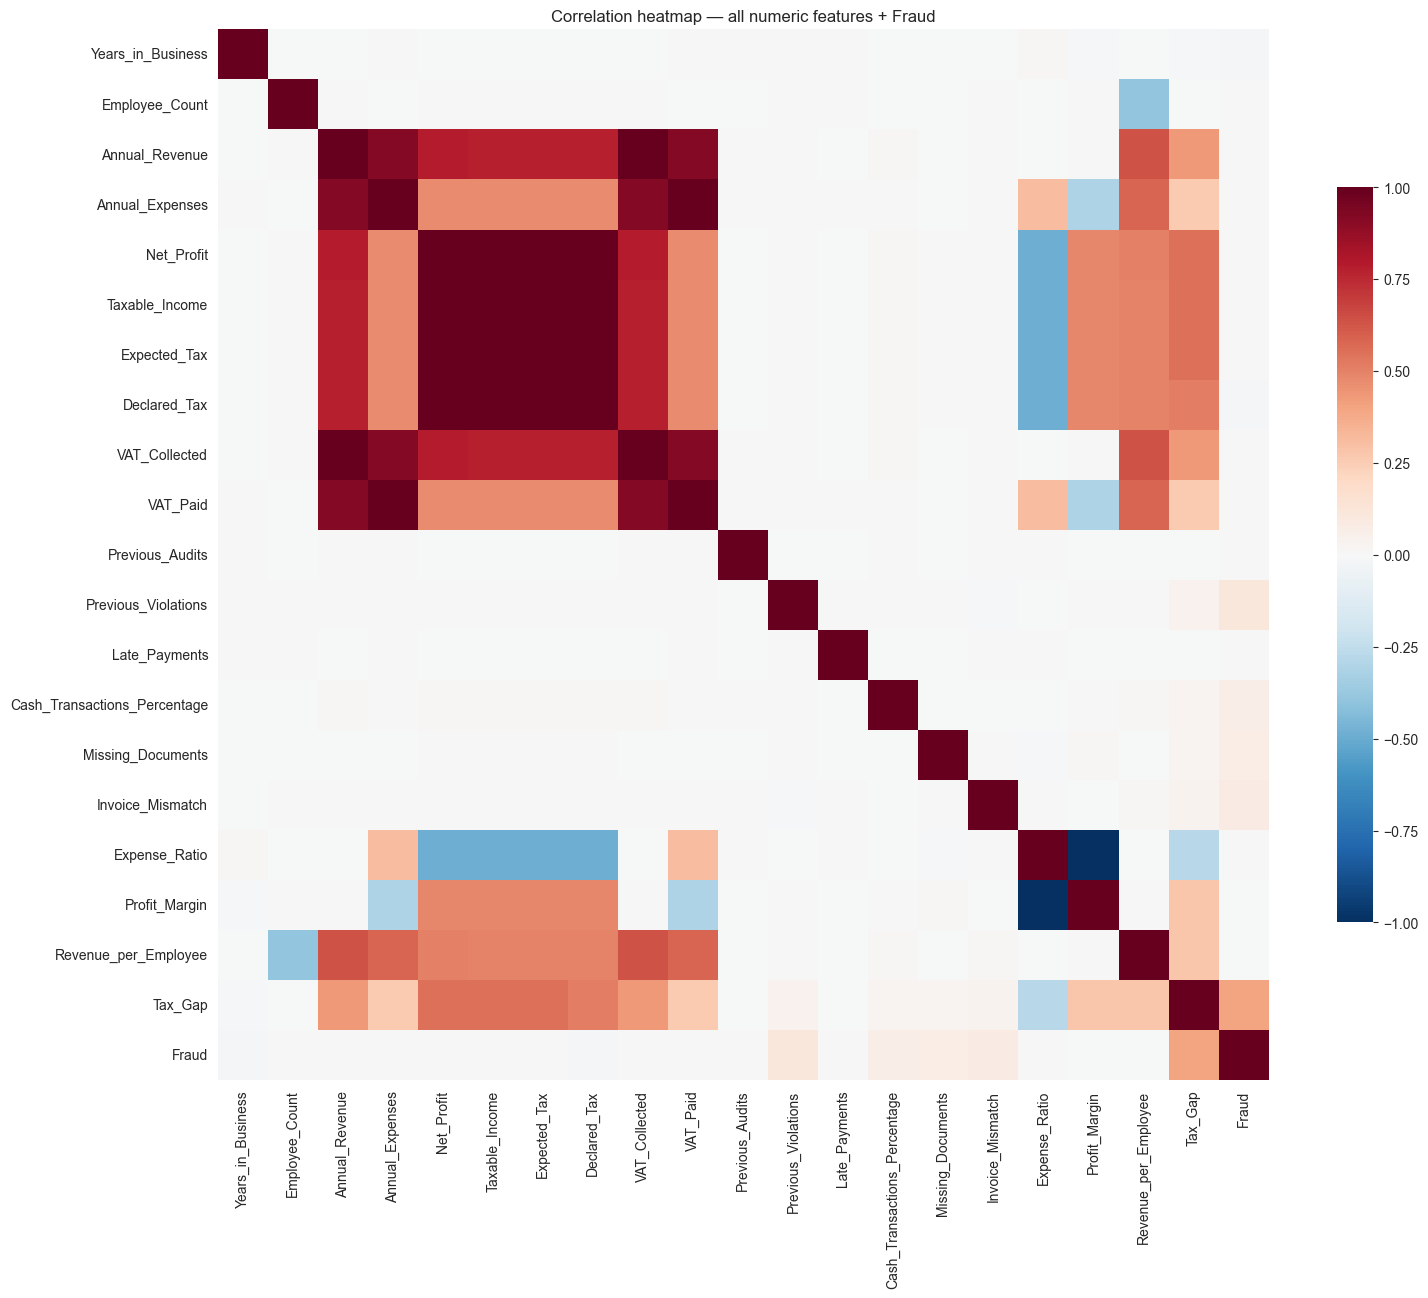

In [12]:
plt.figure(figsize=(16, 13))
corr_matrix = df[num_cols + ['Fraud']].corr()
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, annot=False, square=True,
            cbar_kws={'shrink': 0.7})
plt.title('Correlation heatmap — all numeric features + Fraud')
plt.tight_layout()
plt.show()


In [13]:
# Flag pairs of features that are almost perfectly correlated (|corr| > 0.9, excluding self and Fraud)
corr_no_target = df[num_cols].corr()
pairs = []
for i, c1 in enumerate(num_cols):
    for c2 in num_cols[i+1:]:
        r = corr_no_target.loc[c1, c2]
        if abs(r) > 0.9:
            pairs.append((c1, c2, round(r, 3)))

pairs_df = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'correlation']).sort_values(
    'correlation', key=abs, ascending=False)
pairs_df


,feature_1,feature_2,correlation
1,Annual_Revenue,VAT_Collected,1.000
4,Annual_Expenses,VAT_Paid,1.000
8,Taxable_Income,Expected_Tax,1.000
12,Expense_Ratio,Profit_Margin,-1.000
9,Taxable_Income,Declared_Tax,0.999
10,Expected_Tax,Declared_Tax,0.999
5,Net_Profit,Taxable_Income,0.998
6,Net_Profit,Expected_Tax,0.998
7,Net_Profit,Declared_Tax,0.997
3,Annual_Expenses,VAT_Collected,0.920


In [14]:
# Verify a few of these are exact formulas, not coincidence
checks = [
    ('Annual_Revenue', 'VAT_Collected'),
    ('Annual_Expenses', 'VAT_Paid'),
    ('Taxable_Income', 'Expected_Tax'),
]
for a, b in checks:
    ratio = df[b] / df[a]
    print(f"{b} / {a}  ->  min={ratio.min():.4f}, max={ratio.max():.4f}  (constant = exact formula)")

expense_profit_sum = df['Expense_Ratio'] + df['Profit_Margin']
print(f"\nExpense_Ratio + Profit_Margin -> min={expense_profit_sum.min():.4f}, max={expense_profit_sum.max():.4f}")


VAT_Collected / Annual_Revenue  ->  min=0.1400, max=0.1400  (constant = exact formula)
VAT_Paid / Annual_Expenses  ->  min=0.1400, max=0.1400  (constant = exact formula)
Expected_Tax / Taxable_Income  ->  min=0.2250, max=0.2250  (constant = exact formula)

Expense_Ratio + Profit_Margin -> min=1.0000, max=1.0000


**Key finding — several features are exact mathematical duplicates:**

- `VAT_Collected` = 14% of `Annual_Revenue`, always (a fixed VAT rate)
- `VAT_Paid` = 14% of `Annual_Expenses`, always
- `Expected_Tax` = 22.5% of `Taxable_Income`, always (a fixed tax rate)
- `Expense_Ratio` + `Profit_Margin` = 1, always (they're complements of each other)
- `Net_Profit` and `Taxable_Income` are nearly identical (corr ≈ 0.998, `Taxable_Income` is `Net_Profit` minus a small variable deduction)

None of this is a data quality problem — it's just how these figures are
legally/mathematically defined. But for **feature selection**, keeping both
sides of each pair adds no new information and can distort models that are
sensitive to multicollinearity (e.g. logistic regression). We'll want to
drop one from each redundant pair when we get to feature engineering
(tree-based models like Random Forest / XGBoost are more tolerant of this,
but it's still cleaner to remove the duplication).


## 9. Closer Look at the Strongest Predictors

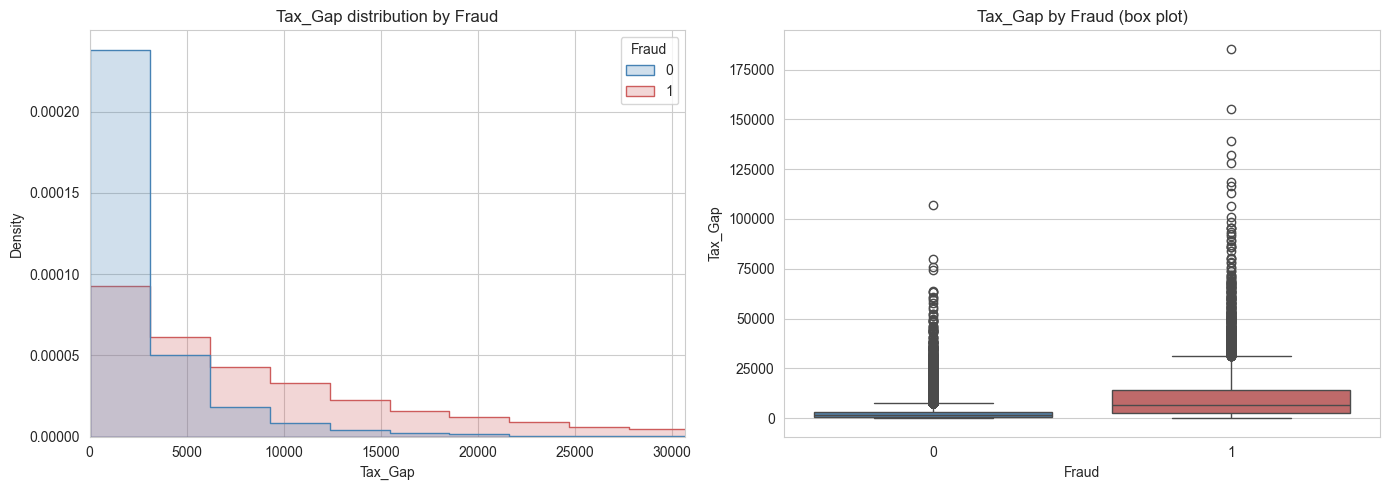

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Tax_Gap', hue='Fraud', palette=PALETTE, bins=60,
             element='step', stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Tax_Gap distribution by Fraud')
axes[0].set_xlim(0, df['Tax_Gap'].quantile(0.99))

sns.boxplot(x='Fraud', y='Tax_Gap', data=df, hue='Fraud', palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title('Tax_Gap by Fraud (box plot)')
plt.tight_layout()
plt.show()


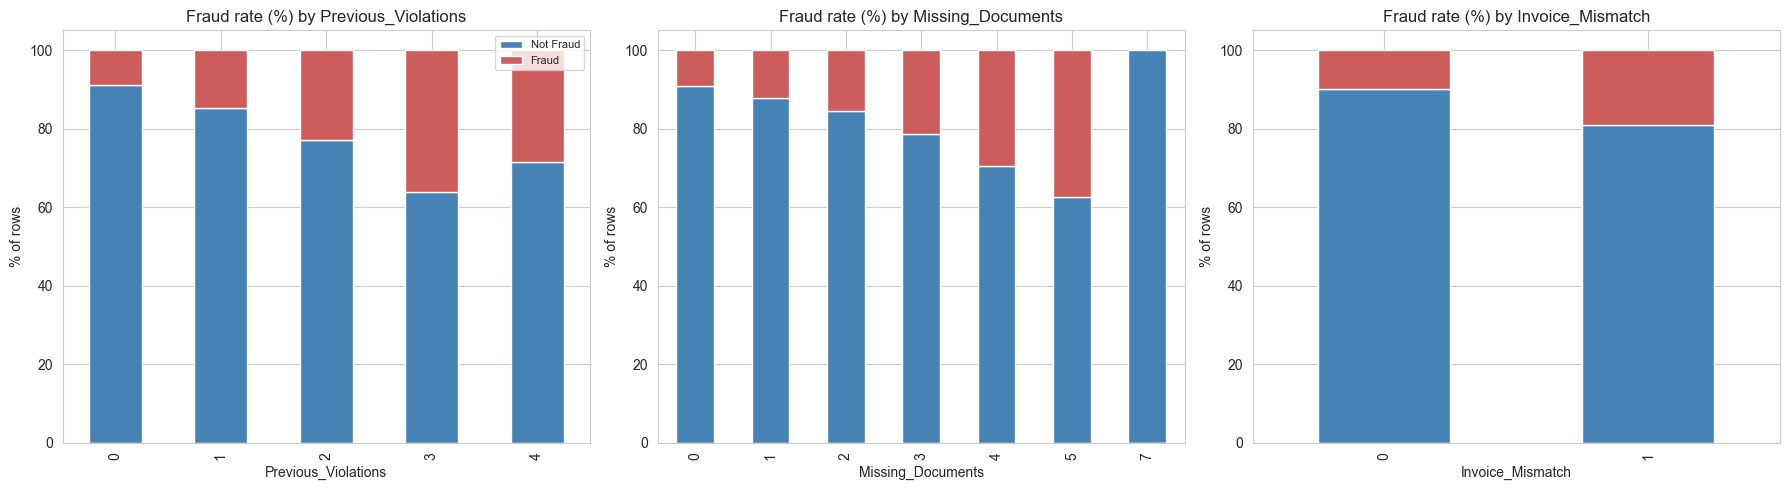

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Previous_Violations', 'Missing_Documents', 'Invoice_Mismatch']):
    ct = pd.crosstab(df[col], df['Fraud'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, color=[PALETTE[0], PALETTE[1]], ax=ax, legend=False)
    ax.set_title(f'Fraud rate (%) by {col}')
    ax.set_ylabel('% of rows')
    ax.set_xlabel(col)

axes[0].legend(['Not Fraud', 'Fraud'], fontsize=8)
plt.tight_layout()
plt.show()


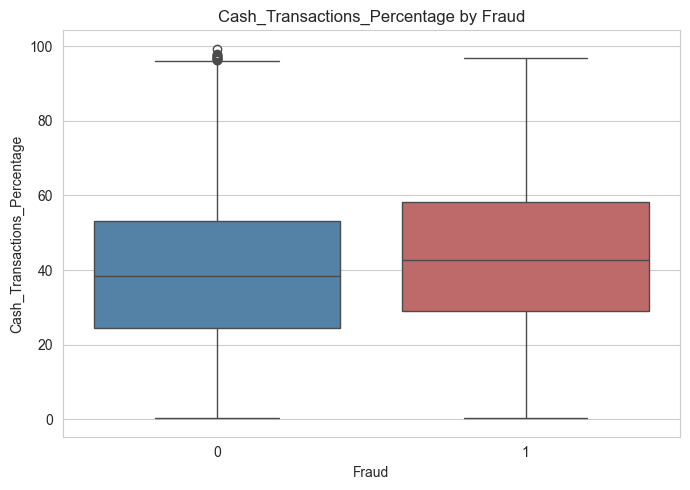

In [17]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Fraud', y='Cash_Transactions_Percentage', data=df, hue='Fraud',
            palette=PALETTE, legend=False)
plt.title('Cash_Transactions_Percentage by Fraud')
plt.tight_layout()
plt.show()


- `Tax_Gap` clearly separates the two classes — fraud cases skew toward
  much larger gaps between expected and declared tax.
- Fraud rate rises steadily as `Previous_Violations` and `Missing_Documents`
  increase, and roughly doubles when `Invoice_Mismatch = 1`.
- `Cash_Transactions_Percentage` shows a real but noisier separation — high
  cash usage leans fraud, but with a lot of overlap.


## 10. Multivariate View — Combining the Top Signals

Does combining `Tax_Gap` with a behavioral flag separate fraud even more
clearly than either alone?


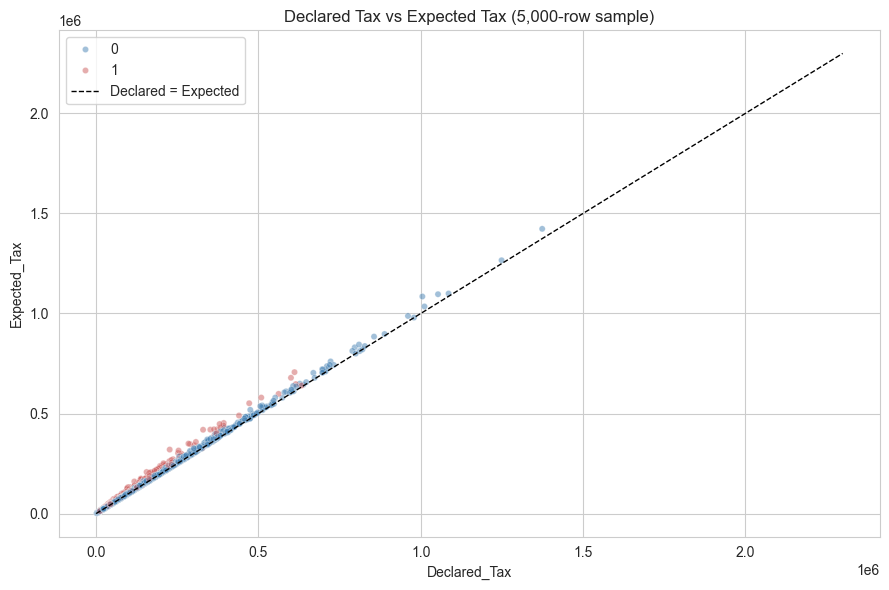

In [18]:
plt.figure(figsize=(9, 6))
sample = df.sample(5000, random_state=42)  # subsample for a readable scatter plot
sns.scatterplot(data=sample, x='Declared_Tax', y='Expected_Tax', hue='Fraud',
                 palette=PALETTE, alpha=0.5, s=20)
plt.plot([0, df['Expected_Tax'].max()], [0, df['Expected_Tax'].max()],
         color='black', linestyle='--', linewidth=1, label='Declared = Expected')
plt.title('Declared Tax vs Expected Tax (5,000-row sample)')
plt.legend()
plt.tight_layout()
plt.show()


Fraud cases sit visibly further below the "Declared = Expected" line —
i.e. they declare noticeably less tax than they should relative to what's
expected, which is exactly what `Tax_Gap` captures numerically.


## 11. Summary of Findings

**Class imbalance:** ~10.7% fraud / ~89.3% not fraud. Modeling will need
class weighting, resampling, or threshold tuning, and evaluation should
rely on precision/recall/F1/ROC-AUC/PR-AUC rather than plain accuracy.

**Strongest predictors of fraud (ranked):**
1. `Tax_Gap` — by far the dominant signal
2. `Previous_Violations`
3. `Invoice_Mismatch`
4. `Missing_Documents`
5. `Cash_Transactions_Percentage`
6. `Business_Type` / `Industry_Risk` (Construction, Import/Export, and
   "High" risk industries fraud noticeably more)

**Little to no standalone signal:** `Annual_Revenue`, `Annual_Expenses`,
`Net_Profit`, `Taxable_Income`, VAT columns, `Employee_Count`,
`Years_in_Business`, `Region`, `Previous_Audits`, `Late_Payments` — business
size and location barely matter here; behavior does.

**Multicollinearity to resolve before/during feature engineering:**
- `VAT_Collected` ≈ 14% × `Annual_Revenue` (redundant)
- `VAT_Paid` ≈ 14% × `Annual_Expenses` (redundant)
- `Expected_Tax` ≈ 22.5% × `Taxable_Income` (redundant)
- `Expense_Ratio` + `Profit_Margin` = 1 (redundant, keep one)
- `Net_Profit` ≈ `Taxable_Income` (corr ≈ 0.998, near-redundant)

**`Tax_Gap` needs a deliberate decision:** it's the strongest predictor by
far, and it's derived directly from `Expected_Tax` and `Declared_Tax`. Worth
discussing whether to keep it as-is (it's a legitimate real-world audit
signal), or engineer it differently, before training a model that may end
up leaning on it almost exclusively.

---
**Next steps:** data preprocessing (encoding categoricals, scaling,
handling the redundant/collinear columns found above) and feature
engineering/selection, before model training.
